In [35]:
import numpy as np
from ase import units
from ase.lattice.cubic import FaceCenteredCubic
from ase.md.nose_hoover_chain import NoseHooverChainNVT
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
from ase.calculators.lj import LennardJones
from ase.io import Trajectory
import os
from asetools.asetools.analysis.rdf import rdf

# System parameters in reduced units
rho_reduced = 0.3    # Target reduced density
T_reduced = 1.2      # Reduced temperature
r_end = 3.3          # Cutoff distance in σ

# Hydrogen LJ parameters
epsilon_H2 = 0.0295 * units.eV  # ε in eV
sigma_H2 = 2.96                 # σ in Angstroms
mass_H2 = 1.0                   # mass in amu

# Calculate correct lattice parameter
def get_unit_len(rho, N_unitcell):
    """Calculate lattice parameter to achieve target density"""
    L = (N_unitcell / rho) ** (1/3)
    return L

# For FCC, there are 4 atoms per unit cell
N_unitcell = 4
size = 4  # 4x4x4 system
L = get_unit_len(rho_reduced, N_unitcell)
L_angstrom = L * sigma_H2

# Create FCC lattice
atoms = FaceCenteredCubic(
    directions=[[1,0,0], [0,1,0], [0,0,1]],
    size=(size,size,size),
    symbol='H',  
    latticeconstant=L_angstrom,
    pbc=(1,1,1)
)

# Set masses
atoms.set_masses(np.ones(len(atoms)) * mass_H2)

# Set up Lennard-Jones calculator
atoms.calc = LennardJones(
    epsilon=epsilon_H2,
    sigma=sigma_H2,
    rc=r_end*sigma_H2
)

# Calculate temperature in Kelvin
temperature = T_reduced * epsilon_H2 / units.kB

# Initialize velocities
MaxwellBoltzmannDistribution(atoms, temperature_K=temperature, force_temp=True)
Stationary(atoms)

# Setup thermostat
timestep = 1.0 * units.fs
dyn = NoseHooverChainNVT(
    atoms,
    timestep,
    temperature_K=temperature,
    tdamp=100 * units.fs,
    tchain=3,
    tloop=1
)

# Initialize trajectory file
traj = Trajectory('md_trajectory.traj', 'w', atoms)
dyn.attach(traj.write, interval=100)  # Write every 100 steps

# Initialize data storage
md_data = {
    "steps": [],
    "epot_reduced": [],
    "ekin_reduced": [],
    "etotal_reduced": [],
    "temperature_reduced": []
}

# Conversion factors
energy_to_reduced = 1.0 / epsilon_H2
temp_to_reduced = units.kB / epsilon_H2

# Function to log MD data
def log_md():
    imd = dyn.get_number_of_steps()
    
    # Log energies and temperature
    epot = atoms.get_potential_energy() * energy_to_reduced
    ekin = atoms.get_kinetic_energy() * energy_to_reduced
    etot = epot + ekin
    temp = atoms.get_temperature() * temp_to_reduced
    
    md_data["steps"].append(imd)
    md_data["epot_reduced"].append(epot)
    md_data["ekin_reduced"].append(ekin)
    md_data["etotal_reduced"].append(etot)
    md_data["temperature_reduced"].append(temp)
    
    if imd % 100 == 0:
        print(f"Step {imd:>6d}: E*={etot:>8.3f}ε  T*={temp:>6.3f}")

# Attach logging function
dyn.attach(log_md, interval=10)

# Run simulation
print("\nStarting MD simulation...")
print("Will save trajectory snapshots every 100 fs")
dyn.run(10000)

# Close trajectory file
traj.close()

print("\nSimulation complete. Trajectory saved to 'md_trajectory.traj'")

# Calculate RDF
traj = Trajectory('md_trajectory.traj', 'r')
g_r = rdf(traj, idx1="Ar", idx2="Ar")

# Plot RDF
import matplotlib.pyplot as plt

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 12))

# Plot RDF
ax1.plot(g_r[0], g_r[1], 'b-', linewidth=2)
ax1.set_xlabel('r (Å)')
ax1.set_ylabel('g(r)')
ax1.set_title('Radial Distribution Function')
ax1.grid(True)

# Plot energies
ax2.plot(np.array(md_data["steps"]) * timestep / units.fs, 
         md_data["epot_reduced"], label='Potential', linewidth=1)
ax2.plot(np.array(md_data["steps"]) * timestep / units.fs, 
         md_data["ekin_reduced"], label='Kinetic', linewidth=1)
ax2.plot(np.array(md_data["steps"]) * timestep / units.fs, 
         md_data["etotal_reduced"], label='Total', linewidth=1)
ax2.set_xlabel('Time (fs)')
ax2.set_ylabel('Energy (ε)')
ax2.legend()
ax2.grid(True)
ax2.set_title('Energy vs Time')

# Plot temperature
ax3.plot(np.array(md_data["steps"]) * timestep / units.fs, 
         md_data["temperature_reduced"], color='r', linewidth=1)
ax3.set_xlabel('Time (fs)')
ax3.set_ylabel('Temperature (kT/ε)')
ax3.grid(True)
ax3.set_title('Temperature vs Time')

plt.tight_layout()
plt.show()


Starting MD simulation...
Will save trajectory snapshots every 100 fs
Step      0: E*= 175.771ε  T*= 1.200


KeyboardInterrupt: 

In [21]:
from ase.io.trajectory import Trajectory

traj = Trajectory("/Users/francescapagano/mdgrad_mini/md_trajectory.traj")

In [22]:
from ase.visualize import view

# Read in the last image.
vis_atoms = traj[-1].copy()

# Wrap structure around the periodic boundaries.
vis_atoms.wrap()

# Translate for better viewing.
center = vis_atoms.cell.diagonal()
vis_atoms.set_positions(vis_atoms.get_positions() - center)
vis_atoms.translate([10, 15, -30])

view(vis_atoms, viewer="x3d")

In [23]:
atoms

Lattice(symbols='H256', pbc=True, cell=[28.07574448344156, 28.07574448344156, 28.07574448344156], masses=..., momenta=..., calculator=LennardJones(...))

In [24]:
from asetools.asetools.analysis.rdf import rdf

g_r = rdf(traj, idx1='H', idx2='H')


g_r

[(-0.05013525800614564, 0.0),
 (0.05013525800614564, 0.0),
 (0.1504057740184369, 0.0),
 (0.2506762900307282, 0.0),
 (0.3509468060430195, 0.0),
 (0.4512173220553108, 0.0),
 (0.551487838067602, 0.0),
 (0.6517583540798934, 0.0),
 (0.7520288700921847, 0.0),
 (0.8522993861044759, 0.0),
 (0.9525699021167672, 0.0),
 (1.0528404181290585, 0.0),
 (1.1531109341413497, 0.0),
 (1.253381450153641, 0.0),
 (1.3536519661659323, 0.0),
 (1.4539224821782235, 0.0),
 (1.554192998190515, 0.0),
 (1.6544635142028061, 0.0),
 (1.7547340302150976, 0.0),
 (1.8550045462273888, 0.0),
 (1.95527506223968, 0.0),
 (2.055545578251971, 0.0),
 (2.155816094264263, 0.0),
 (2.256086610276554, 0.0),
 (2.356357126288845, 0.0),
 (2.4566276423011364, 0.007914131496569235),
 (2.5568981583134276, 0.1055251340947565),
 (2.657168674325719, 0.4855497014053134),
 (2.7574391903380104, 1.1600015059710802),
 (2.8577097063503016, 1.842282660150126),
 (2.957980222362593, 2.263552252775911),
 (3.058250738374884, 2.352461585375714),
 (3.15852

Text(0, 0.5, '$g(r)$ ')

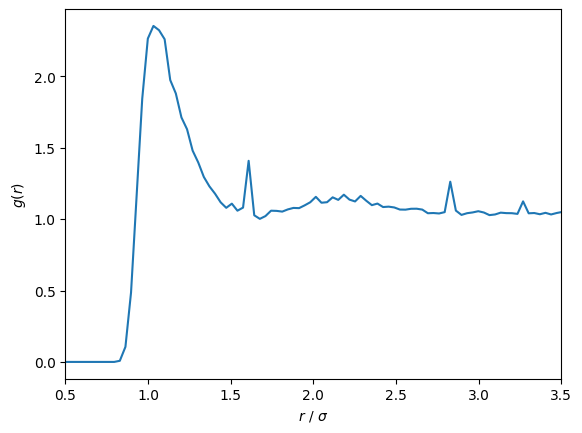

In [44]:
import matplotlib.pyplot as plt

x, y = zip(*g_r)
x = np.array(x) / sigma_H2
plt.plot(x, y)
plt.xlim([0.5,3.5])
plt.xlabel("$r$ / $\sigma$")
plt.ylabel("$g(r)$ ")


In [45]:
view(atoms)

<Popen: returncode: None args: ['/Users/francescapagano/miniconda3/envs/myen...>

2025-02-20 01:34:33.485 python[23994:17759338] +[IMKClient subclass]: chose IMKClient_Legacy
2025-02-20 01:34:33.486 python[23994:17759338] +[IMKInputSession subclass]: chose IMKInputSession_Legacy


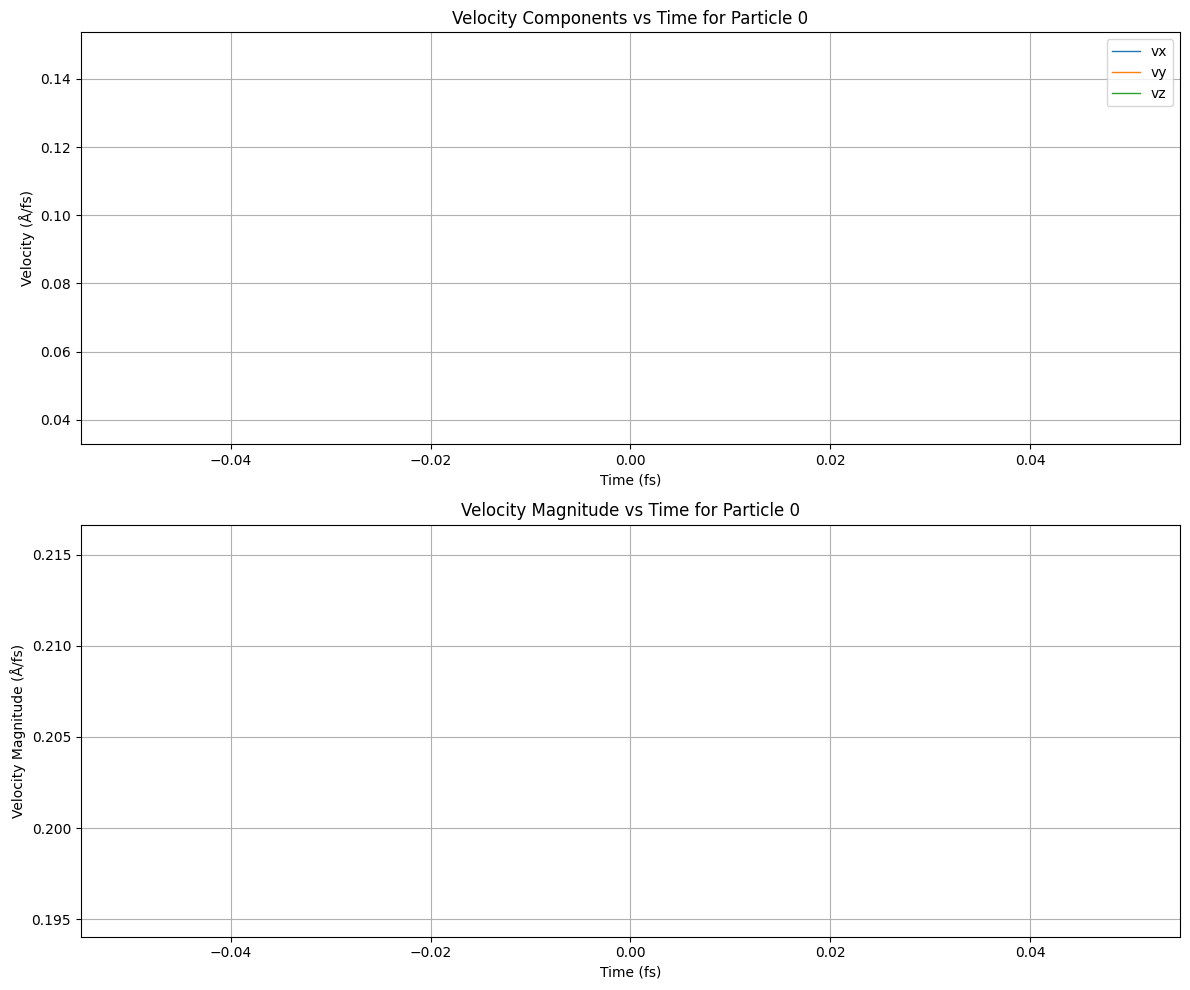


Velocity Statistics for tracked particle:
Average velocity magnitude: 0.205 Å/fs
Maximum velocity magnitude: 0.205 Å/fs
Minimum velocity magnitude: 0.205 Å/fs

Velocity data saved to 'particle_velocities.npz'


In [46]:
from ase.io import Trajectory
import numpy as np
import matplotlib.pyplot as plt

# Read the trajectory file
traj = Trajectory('md_trajectory.traj', 'r')

# Initialize data storage for a single particle (particle 0)
tracked_particle = 0
velocity_data = {
    "frame": [],
    "vx": [],
    "vy": [],
    "vz": [],
    "v_magnitude": []
}

# Extract velocities for the tracked particle
for i, atoms in enumerate(traj):
    velocities = atoms.get_velocities()[tracked_particle]
    v_mag = np.linalg.norm(velocities)
    
    velocity_data["frame"].append(i)
    velocity_data["vx"].append(velocities[0])
    velocity_data["vy"].append(velocities[1])
    velocity_data["vz"].append(velocities[2])
    velocity_data["v_magnitude"].append(v_mag)

# Convert to numpy arrays for easier manipulation
frames = np.array(velocity_data["frame"])
time = frames * 100  # Since trajectory was saved every 100 fs

# Create plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot velocity components
ax1.plot(time, velocity_data["vx"], label='vx', linewidth=1)
ax1.plot(time, velocity_data["vy"], label='vy', linewidth=1)
ax1.plot(time, velocity_data["vz"], label='vz', linewidth=1)
ax1.set_xlabel('Time (fs)')
ax1.set_ylabel('Velocity (Å/fs)')
ax1.legend()
ax1.grid(True)
ax1.set_title(f'Velocity Components vs Time for Particle {tracked_particle}')

# Plot velocity magnitude
ax2.plot(time, velocity_data["v_magnitude"], 
         color='r', linewidth=1)
ax2.set_xlabel('Time (fs)')
ax2.set_ylabel('Velocity Magnitude (Å/fs)')
ax2.grid(True)
ax2.set_title(f'Velocity Magnitude vs Time for Particle {tracked_particle}')

plt.tight_layout()
plt.show()

# Print some statistics
print("\nVelocity Statistics for tracked particle:")
print(f"Average velocity magnitude: {np.mean(velocity_data['v_magnitude']):.3f} Å/fs")
print(f"Maximum velocity magnitude: {np.max(velocity_data['v_magnitude']):.3f} Å/fs")
print(f"Minimum velocity magnitude: {np.min(velocity_data['v_magnitude']):.3f} Å/fs")

# Optional: Save the velocity data to a file
np.savez('particle_velocities.npz',
         time=time,
         vx=velocity_data["vx"],
         vy=velocity_data["vy"],
         vz=velocity_data["vz"],
         v_magnitude=velocity_data["v_magnitude"])

print("\nVelocity data saved to 'particle_velocities.npz'")

In [48]:
import numpy as np
from ase import units
from ase.lattice.cubic import FaceCenteredCubic
from ase.md.nose_hoover_chain import NoseHooverChainNVT
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
from ase.calculators.lj import LennardJones
import matplotlib.pyplot as plt

# System parameters in reduced units
rho_reduced = 0.3    
T_reduced = 1.2      
r_end = 3.3          

# Hydrogen LJ parameters
epsilon_H2 = 0.0295 * units.eV
sigma_H2 = 2.96                 
mass_H2 = 1.0                   

# Setup system
N_unitcell = 4
size = 4  
L = (N_unitcell / rho_reduced) ** (1/3)
L_angstrom = L * sigma_H2

# Create FCC lattice
atoms = FaceCenteredCubic(
    directions=[[1,0,0], [0,1,0], [0,0,1]],
    size=(size,size,size),
    symbol='H',  
    latticeconstant=L_angstrom,
    pbc=(1,1,1)
)

# Set masses and calculator
atoms.set_masses(np.ones(len(atoms)) * mass_H2)
atoms.calc = LennardJones(
    epsilon=epsilon_H2,
    sigma=sigma_H2,
    rc=r_end*sigma_H2
)

# Initialize velocities
temperature = T_reduced * epsilon_H2 / units.kB
MaxwellBoltzmannDistribution(atoms, temperature_K=temperature, force_temp=True)
Stationary(atoms)

# Setup thermostat
timestep = 1.0 * units.fs
dyn = NoseHooverChainNVT(
    atoms,
    timestep,
    temperature_K=temperature,
    tdamp=100 * units.fs,
    tchain=3,
    tloop=1
)

# Initialize data storage for all particles
n_particles = len(atoms)
velocity_data = {
    "time": [],
    "velocities": []  # Will store full velocity arrays
}

# Function to log velocities
def log_velocities():
    imd = dyn.get_number_of_steps()
    time = imd * timestep / units.fs
    
    velocity_data["time"].append(time)
    velocity_data["velocities"].append(atoms.get_velocities().copy())

# Attach logging function
dyn.attach(log_velocities, interval=10)  # Log every 10 steps

# Run simulation
print("\nStarting MD simulation...")
dyn.run(10000)

# Convert lists to numpy arrays for easier handling
times = np.array(velocity_data["time"])
velocities = np.array(velocity_data["velocities"])

# Save velocities to file
np.savez('velocity_trajectory.npz', 
         times=times, 
         velocities=velocities)

print("\nSimulation complete. Analyzing velocities...")

# Plot velocities for particle 0 (can change this index)
particle_idx = 0

# Extract velocity components for the chosen particle
vx = velocities[:, particle_idx, 0]
vy = velocities[:, particle_idx, 1]
vz = velocities[:, particle_idx, 2]
v_mag = np.sqrt(vx**2 + vy**2 + vz**2)

# Create plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot velocity components
ax1.plot(times, vx, label='vx', linewidth=1)
ax1.plot(times, vy, label='vy', linewidth=1)
ax1.plot(times, vz, label='vz', linewidth=1)
ax1.set_xlabel('Time (fs)')
ax1.set_ylabel('Velocity (Å/fs)')
ax1.legend()
ax1.grid(True)
ax1.set_title(f'Velocity Components vs Time for Particle {particle_idx}')

# Plot velocity magnitude
ax2.plot(times, v_mag, color='r', linewidth=1)
ax2.set_xlabel('Time (fs)')
ax2.set_ylabel('Velocity Magnitude (Å/fs)')
ax2.grid(True)
ax2.set_title(f'Velocity Magnitude vs Time for Particle {particle_idx}')

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nVelocity Statistics for particle {particle_idx}:")
print(f"Average velocity magnitude: {np.mean(v_mag):.3f} Å/fs")
print(f"Maximum velocity magnitude: {np.max(v_mag):.3f} Å/fs")
print(f"Minimum velocity magnitude: {np.min(v_mag):.3f} Å/fs")
print(f"\nData points collected: {len(times)}")
print(f"Time range: {times[0]:.1f} to {times[-1]:.1f} fs")


Starting MD simulation...


KeyboardInterrupt: 